# PHASE 3 — EDA & Statistical Analysis
## Delivery Performance & Customer Satisfaction

**Objective:** Explore the cleaned delivery dataset, describe its distributions and relationships, identify important delivery-performance patterns, and produce Python visualizations and statistical findings for the graduation project.

### Main areas
1. Dataset overview
2. Descriptive statistics
3. Distribution analysis
4. Delivery performance analysis
5. Categorical analysis
6. Correlation analysis
7. Time trends
8. Geographic patterns
9. Relationships between variables
10. Statistical analysis
11. Key findings


In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
# Load the final cleaned dataset
DATA_PATH = "final_clean_delivery_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Rows: 100,002
Columns: 32


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,Order_Date,Order_Hour,Order_Day,Order_DayOfWeek,Is_Weekend,Time_Period,Delivery_Speed_kmh,Driver_Order_Count,Is_Delayed
0,1,U3522,358,485,Fried Chicken,3,273.720,2025-06-16 08:32:00,2025-06-16 09:11:00,39.000,Alexandria,Wallet,Delivered,Motorbike,31.195,29.922,31.191,29.905,31.216,29.911,1.666,High,Offline,2025-06-16,8,Monday,Monday,0,Morning,2.563,204,1.000
1,2,U9214,316,65,Sandwich,3,365.820,2025-06-03 21:27:00,2025-06-03 22:00:00,33.000,Zagazig,Credit Card,Delivered,Motorbike,30.606,31.503,30.586,31.486,30.580,31.502,2.739,Low,Online,2025-06-03,21,Tuesday,Tuesday,0,Evening,4.979,185,0.000
2,3,U7307,357,309,Koshary,3,401.940,2025-06-01 14:48:00,2025-06-01 15:26:00,NaN,Assiut,Cash,In Transit,Car,27.190,31.178,27.165,31.169,27.163,31.189,2.929,Medium,Online,2025-06-01,14,Sunday,Sunday,0,Afternoon,NaN,177,NaN
3,4,U3612,420,32,Sushi,2,221.180,2025-06-13 02:30:00,2025-06-13 03:22:00,52.000,Mansoura,Cash,Delivered,Car,31.042,31.381,31.036,31.380,31.055,31.401,0.677,Low,Online,2025-06-13,2,Friday,Friday,1,Night,0.782,164,1.000
4,5,U3492,73,364,Koshary,5,355.550,2025-06-06 09:48:00,2025-06-06 10:32:00,44.000,Mansoura,Wallet,Delivered,Motorbike,31.024,31.376,31.026,31.397,31.035,31.389,1.995,High,Online,2025-06-06,9,Friday,Friday,1,Morning,2.720,190,1.000


## 1. Dataset Overview

The final dataset contains delivery orders with order, customer, restaurant, driver, geographic, payment, traffic, availability, and delivery-performance information.

We first confirm the structure before starting the analysis.


In [3]:
# Structure and data types
overview = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isna().sum().values,
    "Unique Values": df.nunique(dropna=False).values
})

display(overview)


,Column,Data Type,Missing Values,Unique Values
0,Order_ID,int64,0,100002
1,User_ID,str,0,9000
2,Restaurant_ID,int64,0,1000
3,Driver_ID,int64,0,500
4,Item_Name,str,0,9
5,Quantity,int64,0,5
6,Total_Price,float64,0,35618
7,Order_Time,str,0,21367
8,Delivery_Time,str,0,21396
9,Delivery_Duration_Minutes,float64,14803,47


In [4]:
# Numeric descriptive statistics
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
display(df[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Order_ID,"100,002.000","50,001.500","28,868.235",1.000,"25,001.250","50,001.500","75,001.750","100,002.000"
Restaurant_ID,"100,002.000",499.833,288.253,1.000,250.000,499.000,750.000,"1,000.000"
Driver_ID,"100,002.000",250.792,144.289,1.000,126.000,251.000,376.000,500.000
Quantity,"100,002.000",2.991,1.410,1.000,2.000,3.000,4.000,5.000
Total_Price,"100,002.000",268.923,170.490,30.000,129.430,233.200,381.507,750.000
Delivery_Duration_Minutes,"85,199.000",37.551,10.062,15.000,30.000,38.000,45.000,60.000
Restaurant_Lat,"100,002.000",30.119,1.272,27.161,30.023,30.587,31.027,31.220
Restaurant_Lon,"100,002.000",31.063,0.488,29.899,31.009,31.209,31.372,31.522
Customer_Lat,"100,002.000",30.119,1.272,27.161,30.023,30.587,31.027,31.220
Customer_Lon,"100,002.000",31.063,0.488,29.899,31.008,31.209,31.372,31.522


## 2. Descriptive Statistics

For the main numerical variables, we examine:
- Mean
- Median
- Standard deviation
- Minimum and maximum
- Quartiles

This gives the central tendency, spread, and range of the delivery data.


In [5]:
# Main delivery-performance statistics
performance_cols = [
    c for c in [
        "Quantity",
        "Total_Price",
        "Delivery_Duration_Minutes",
        "Delivery_Distance_km",
        "Delivery_Speed_kmh"
    ] if c in df.columns
]

display(df[performance_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Quantity,"100,002.000",2.991,1.410,1.000,2.000,3.000,4.000,5.000
Total_Price,"100,002.000",268.923,170.490,30.000,129.430,233.200,381.507,750.000
Delivery_Duration_Minutes,"85,199.000",37.551,10.062,15.000,30.000,38.000,45.000,60.000
Delivery_Distance_km,"100,002.000",2.165,1.038,0.009,1.356,2.123,2.925,5.598
Delivery_Speed_kmh,"85,199.000",3.760,2.227,0.015,2.129,3.413,4.947,19.703


## 3. Distribution Analysis

Distribution plots help identify:
- Concentration of observations
- Skewness
- Spread
- Potential unusual values

The plots below focus on the most important numerical variables.


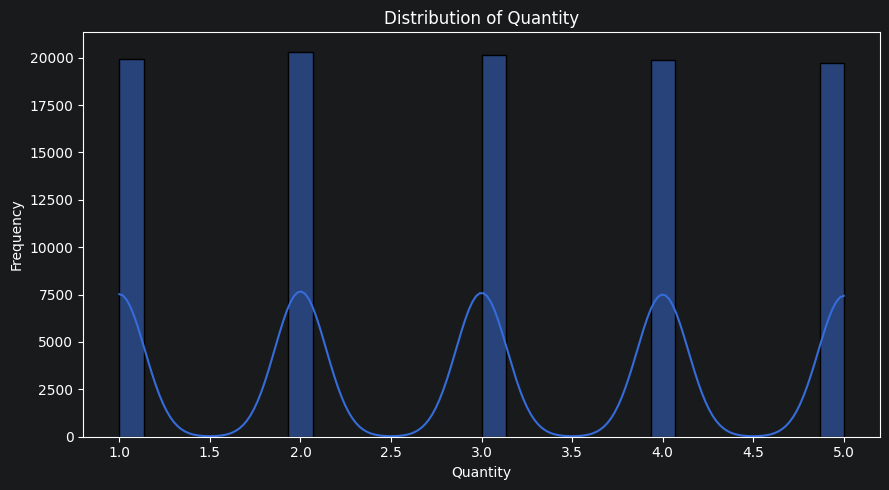

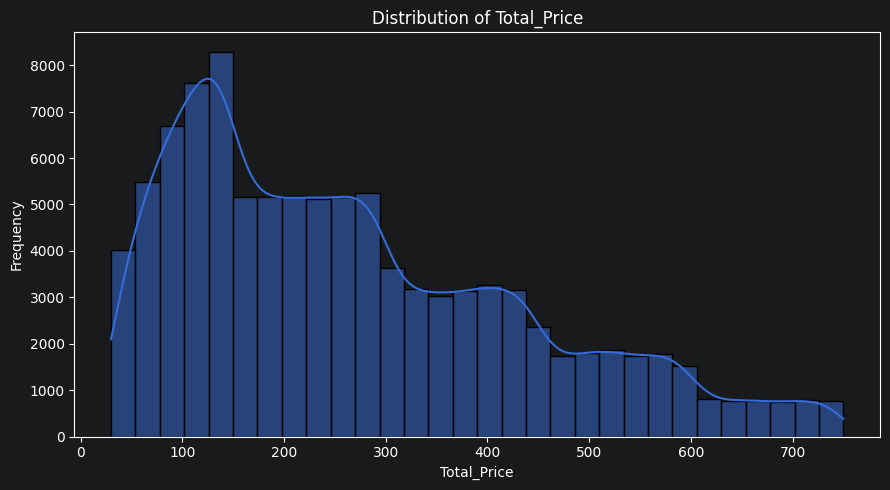

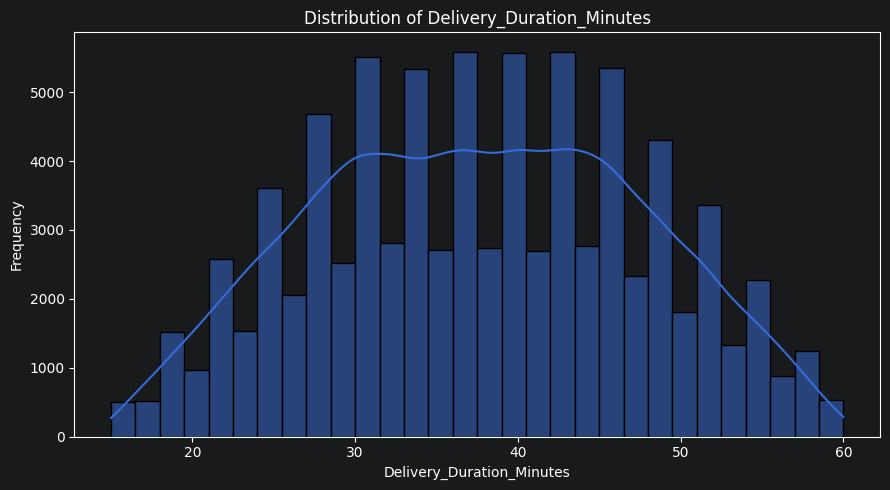

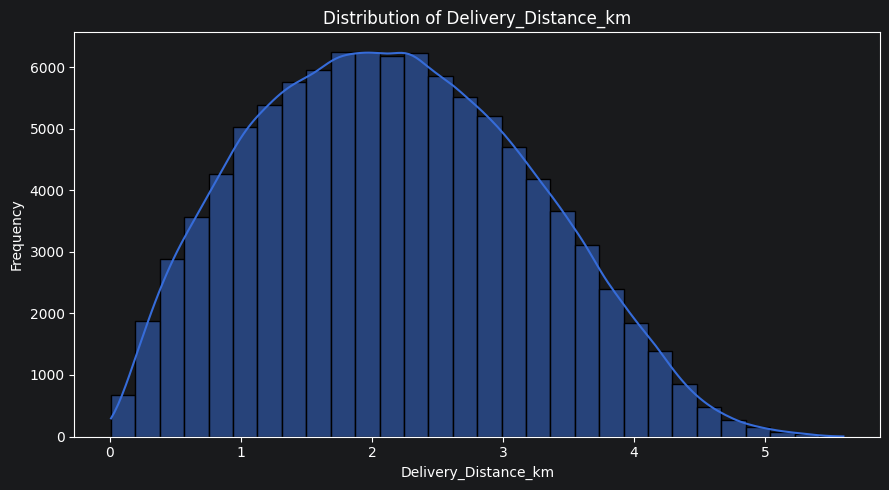

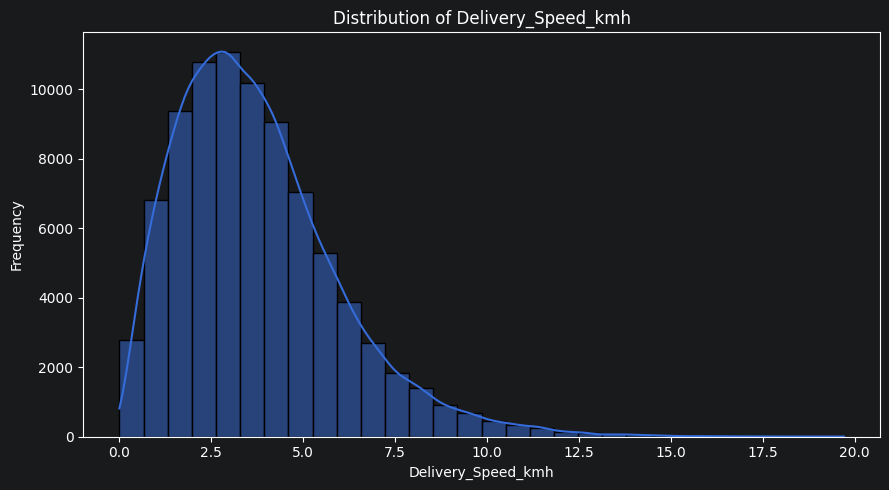

In [6]:
# Histograms for key numerical variables
for col in performance_cols:
    plt.figure(figsize=(9, 5))
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


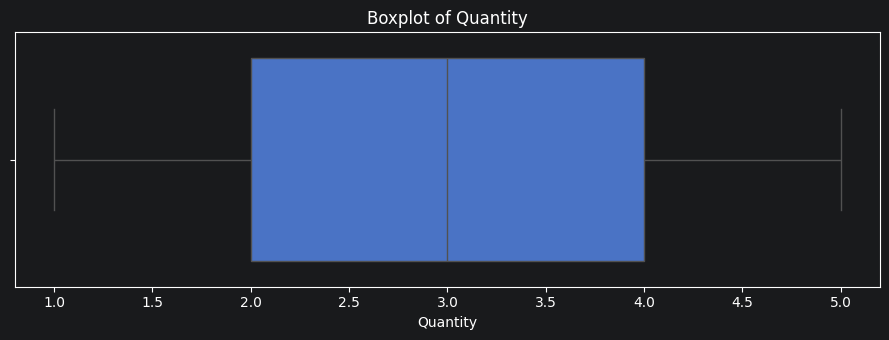

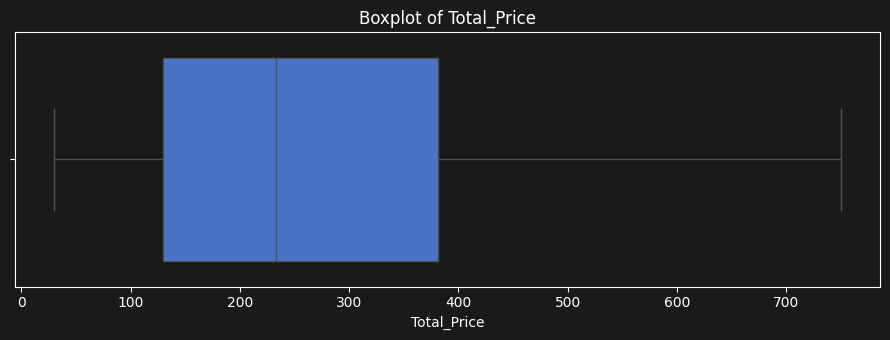

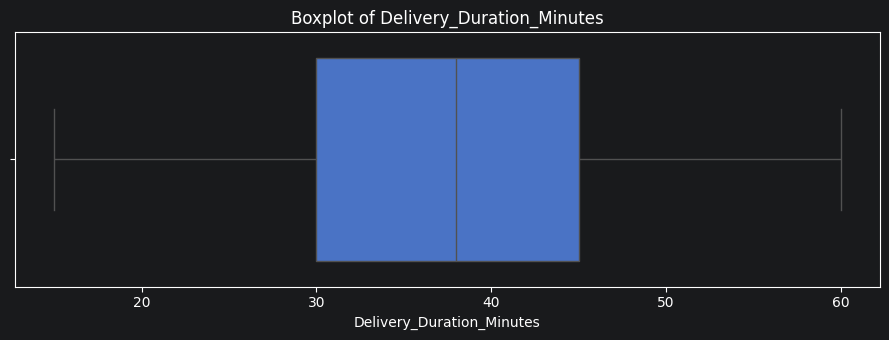

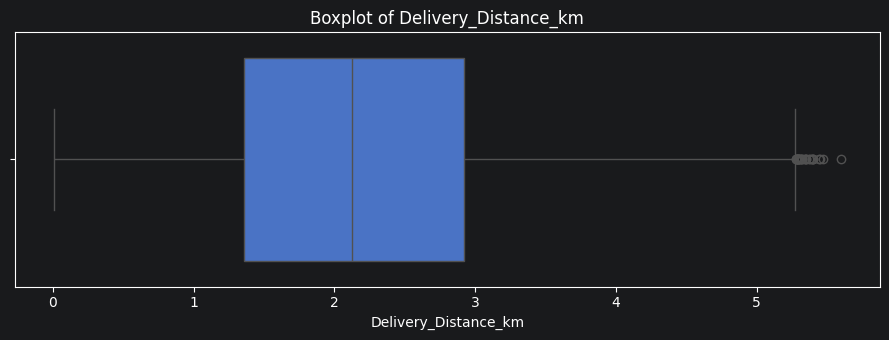

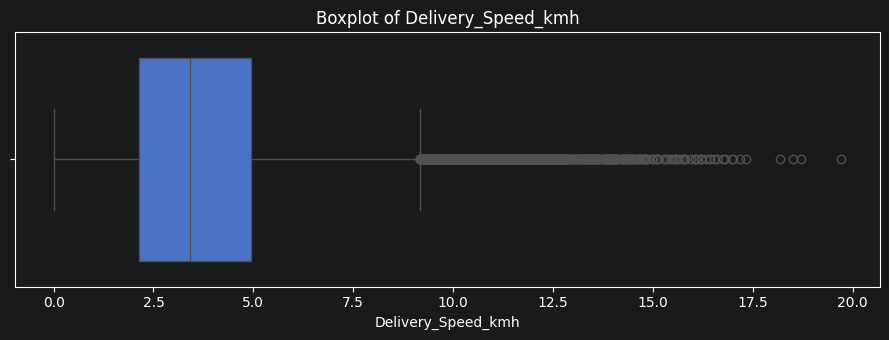

In [7]:
# Boxplots for key numerical variables
for col in performance_cols:
    plt.figure(figsize=(9, 3.5))
    sns.boxplot(x=df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


## 4. Delivery Performance Analysis

Delivery duration and distance are central to the project.

We compare delivery performance across:
- Traffic level
- Driver availability
- Vehicle type
- Order status
- City


In [8]:
# Summary by traffic level
if {"Traffic_Level", "Delivery_Duration_Minutes"}.issubset(df.columns):
    traffic_summary = (
        df.groupby("Traffic_Level")["Delivery_Duration_Minutes"]
          .agg(["count", "mean", "median", "std", "min", "max"])
          .sort_values("mean", ascending=False)
    )
    display(traffic_summary)


,count,mean,median,std,min,max
Traffic_Level,,,,,,
Low,39004,37.602,38.000,10.085,15.000,60.000
Medium,21345,37.567,38.000,10.040,15.000,60.000
High,24850,37.457,37.000,10.043,15.000,60.000


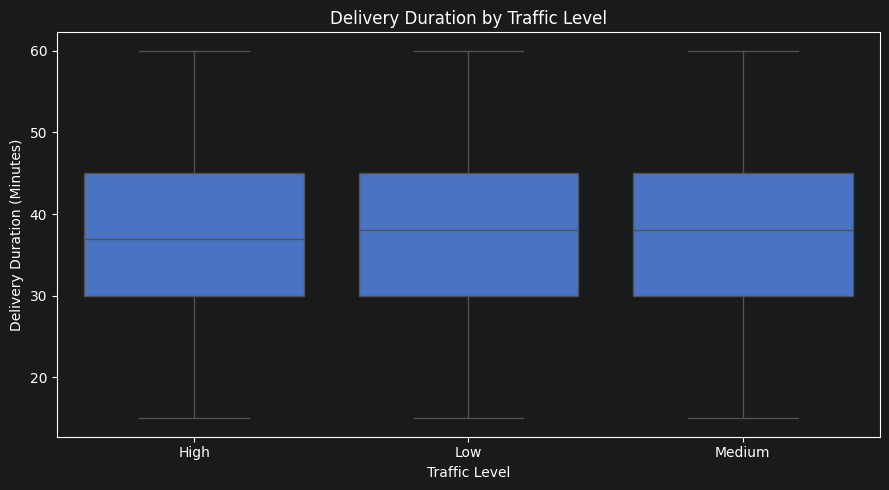

In [9]:
# Delivery duration by traffic level
if {"Traffic_Level", "Delivery_Duration_Minutes"}.issubset(df.columns):
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df, x="Traffic_Level", y="Delivery_Duration_Minutes")
    plt.title("Delivery Duration by Traffic Level")
    plt.xlabel("Traffic Level")
    plt.ylabel("Delivery Duration (Minutes)")
    plt.tight_layout()
    plt.show()


,count,mean,median,std
Driver_Vehicle,,,,
Car,28368,37.601,38.000,10.095
Bicycle,28570,37.565,38.000,10.024
Motorbike,28261,37.487,37.000,10.066


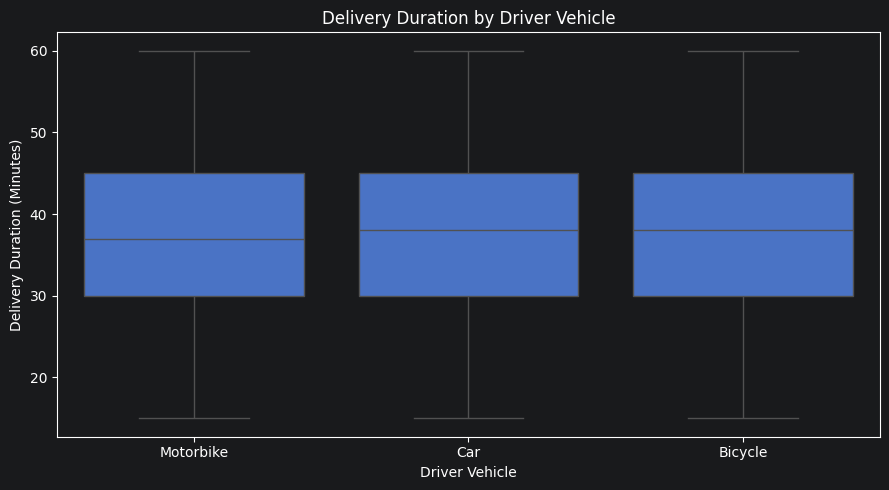

In [10]:
# Delivery duration by vehicle
if {"Driver_Vehicle", "Delivery_Duration_Minutes"}.issubset(df.columns):
    vehicle_summary = (
        df.groupby("Driver_Vehicle")["Delivery_Duration_Minutes"]
          .agg(["count", "mean", "median", "std"])
          .sort_values("mean", ascending=False)
    )
    display(vehicle_summary)

    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df, x="Driver_Vehicle", y="Delivery_Duration_Minutes")
    plt.title("Delivery Duration by Driver Vehicle")
    plt.xlabel("Driver Vehicle")
    plt.ylabel("Delivery Duration (Minutes)")
    plt.tight_layout()
    plt.show()


In [11]:
# Delivery duration by driver availability
if {"Driver_Availability", "Delivery_Duration_Minutes"}.issubset(df.columns):
    availability_summary = (
        df.groupby("Driver_Availability")["Delivery_Duration_Minutes"]
          .agg(["count", "mean", "median", "std"])
          .sort_values("mean", ascending=False)
    )
    display(availability_summary)


,count,mean,median,std
Driver_Availability,,,,
Offline,8434,37.580,38.000,9.988
Online,76765,37.548,38.000,10.070


,Orders
Order_Status,
Delivered,85199
Cancelled,9812
In Transit,4991


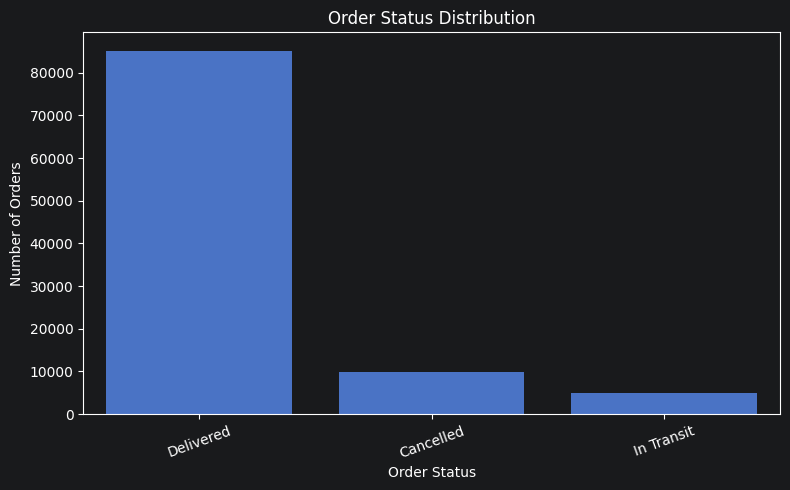

In [12]:
# Order status distribution
if "Order_Status" in df.columns:
    status_counts = df["Order_Status"].value_counts()

    display(status_counts.to_frame("Orders"))

    plt.figure(figsize=(8, 5))
    sns.barplot(x=status_counts.index, y=status_counts.values)
    plt.title("Order Status Distribution")
    plt.xlabel("Order Status")
    plt.ylabel("Number of Orders")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


## 5. Categorical Analysis

We inspect important categorical variables to understand order composition and whether delivery performance differs between groups.


In [13]:
categorical_cols = [
    c for c in [
        "City", "Payment_Method", "Order_Status",
        "Driver_Vehicle", "Traffic_Level",
        "Driver_Availability", "Item_Name"
    ] if c in df.columns
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False).to_frame("Count"))



--- City ---


,Count
City,
Zagazig,14538
Cairo,14382
Tanta,14336
Assiut,14302
Giza,14232
Alexandria,14168
Mansoura,14044



--- Payment_Method ---


,Count
Payment_Method,
Cash,33528
Wallet,33251
Credit Card,33223



--- Order_Status ---


...

,Count
Traffic_Level,
Low,45826
High,29221
Medium,24955



--- Driver_Availability ---


,Count
Driver_Availability,
Online,90113
Offline,9889



--- Item_Name ---


,Count
Item_Name,
Shawarma,11320
Pizza,11230
Fried Chicken,11171
Burger,11130
Pasta,11077
Sandwich,11061
Koshary,11033
Sushi,10990
Salad,10990


,count,mean,median,std
City,,,,
Zagazig,12450,37.674,38.000,10.029
Mansoura,11946,37.635,38.000,10.064
Assiut,12220,37.615,38.000,10.071
Tanta,12132,37.571,37.000,10.097
Alexandria,12111,37.467,37.000,10.037
Cairo,12246,37.454,37.000,10.054
Giza,12094,37.440,37.000,10.080


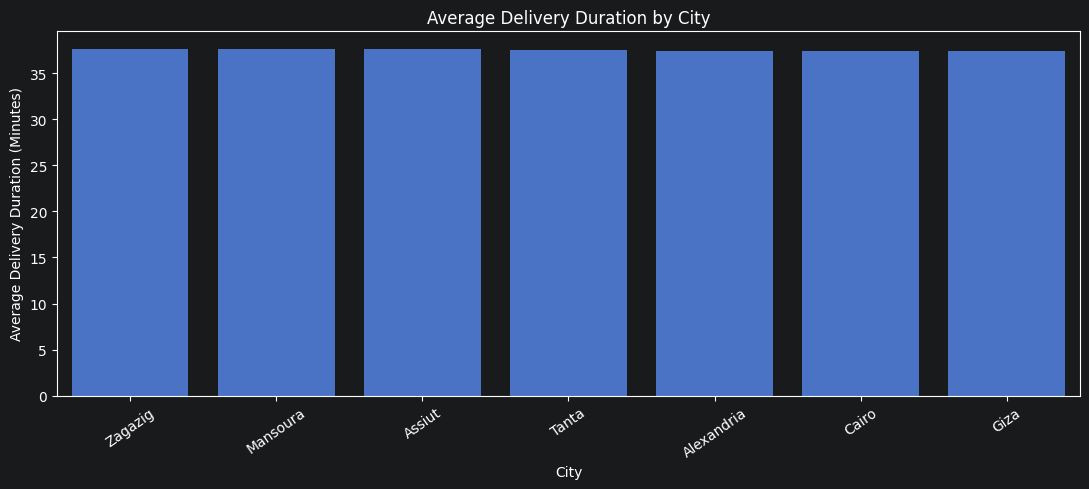

In [14]:
# Average delivery duration by city
if {"City", "Delivery_Duration_Minutes"}.issubset(df.columns):
    city_duration = (
        df.groupby("City")["Delivery_Duration_Minutes"]
          .agg(["count", "mean", "median", "std"])
          .sort_values("mean", ascending=False)
    )
    display(city_duration)

    plt.figure(figsize=(11, 5))
    sns.barplot(
        data=city_duration.reset_index(),
        x="City",
        y="mean"
    )
    plt.title("Average Delivery Duration by City")
    plt.xlabel("City")
    plt.ylabel("Average Delivery Duration (Minutes)")
    plt.xticks(rotation=35)
    plt.tight_layout()
    plt.show()


In [15]:
# Average order value by item
if {"Item_Name", "Total_Price"}.issubset(df.columns):
    item_summary = (
        df.groupby("Item_Name")["Total_Price"]
          .agg(["count", "mean", "median"])
          .sort_values("mean", ascending=False)
    )
    display(item_summary)


,count,mean,median
Item_Name,,,
Koshary,11033,270.537,235.760
Shawarma,11320,270.342,235.660
Salad,10990,269.758,231.255
Pizza,11230,269.517,234.870
Pasta,11077,269.237,232.840
Fried Chicken,11171,269.207,234.840
Burger,11130,267.585,231.325
Sandwich,11061,267.141,230.220
Sushi,10990,266.940,231.330


## 6. Correlation Analysis

Correlation analysis examines linear relationships among numerical variables.

Important caution: correlation measures association, not causation.


,Quantity,Total_Price,Delivery_Duration_Minutes,Delivery_Distance_km,Delivery_Speed_kmh
Quantity,1.000,0.741,-0.000,0.004,0.005
Total_Price,0.741,1.000,-0.004,0.005,0.008
Delivery_Duration_Minutes,-0.000,-0.004,1.000,-0.000,-0.501
Delivery_Distance_km,0.004,0.005,-0.000,1.000,0.809
Delivery_Speed_kmh,0.005,0.008,-0.501,0.809,1.000


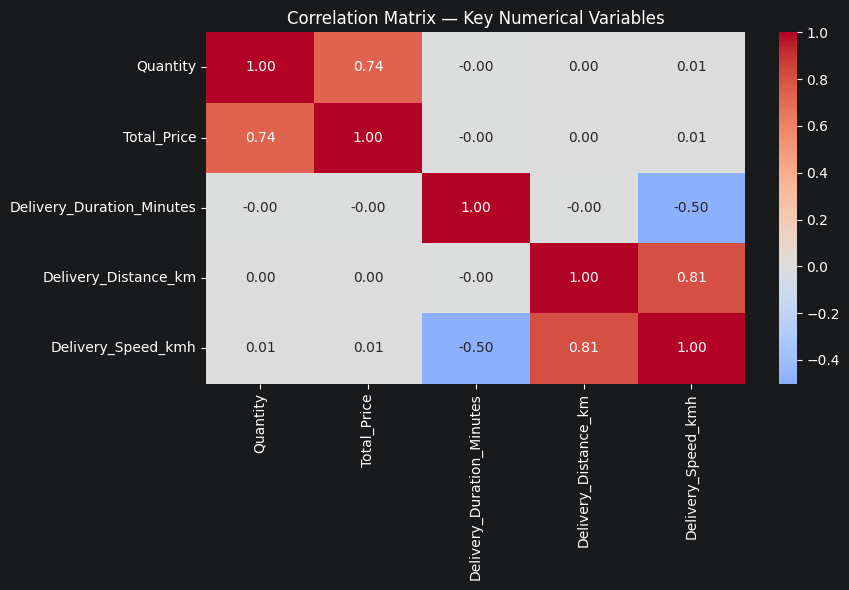

In [16]:
corr_cols = [c for c in [
    "Quantity", "Total_Price", "Delivery_Duration_Minutes",
    "Delivery_Distance_km", "Delivery_Speed_kmh"
] if c in df.columns]

corr_matrix = df[corr_cols].corr(numeric_only=True)

display(corr_matrix)

plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Key Numerical Variables")
plt.tight_layout()
plt.show()


## 7. Time Trend Analysis

Order and delivery timestamps are used to derive:
- Order date
- Year
- Month
- Day of week
- Hour

This allows us to investigate changes in order activity and delivery performance over time.


In [17]:
# Parse timestamps
for col in ["Order_Time", "Delivery_Time"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

if "Order_Time" in df.columns:
    df["Order_Date"] = df["Order_Time"].dt.date
    df["Order_Year"] = df["Order_Time"].dt.year
    df["Order_Month"] = df["Order_Time"].dt.month
    df["Order_Month_Name"] = df["Order_Time"].dt.month_name()
    df["Order_DayOfWeek"] = df["Order_Time"].dt.day_name()
    df["Order_Hour"] = df["Order_Time"].dt.hour

display(df[["Order_Time", "Order_Year", "Order_Month", "Order_DayOfWeek", "Order_Hour"]].head())


,Order_Time,Order_Year,Order_Month,Order_DayOfWeek,Order_Hour
0,2025-06-16 08:32:00,2025,6,Monday,8
1,2025-06-03 21:27:00,2025,6,Tuesday,21
2,2025-06-01 14:48:00,2025,6,Sunday,14
3,2025-06-13 02:30:00,2025,6,Friday,2
4,2025-06-06 09:48:00,2025,6,Friday,9


,Orders
Order_Year,
2025,100002


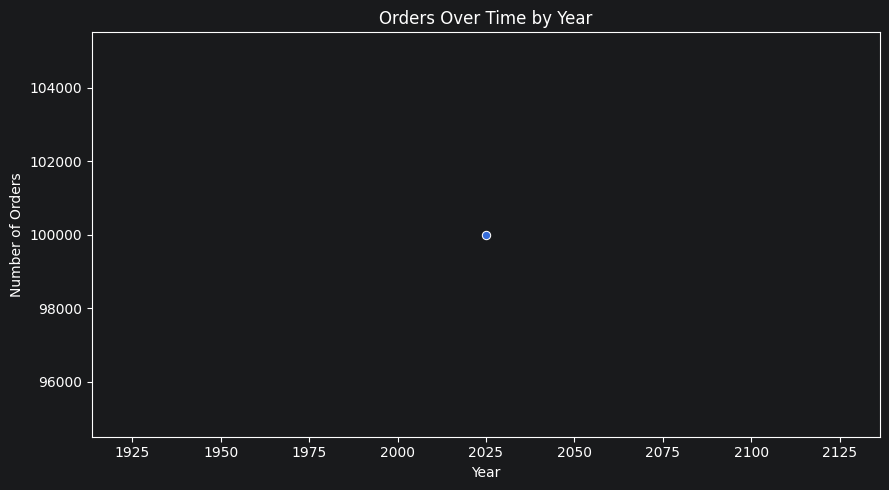

In [18]:
# Orders by year
if "Order_Year" in df.columns:
    yearly_orders = df.groupby("Order_Year").size().rename("Orders")
    display(yearly_orders.to_frame())

    plt.figure(figsize=(9, 5))
    sns.lineplot(x=yearly_orders.index, y=yearly_orders.values, marker="o")
    plt.title("Orders Over Time by Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Orders")
    plt.tight_layout()
    plt.show()


,Average_Delivery_Duration
Order_Month,
6,37.551


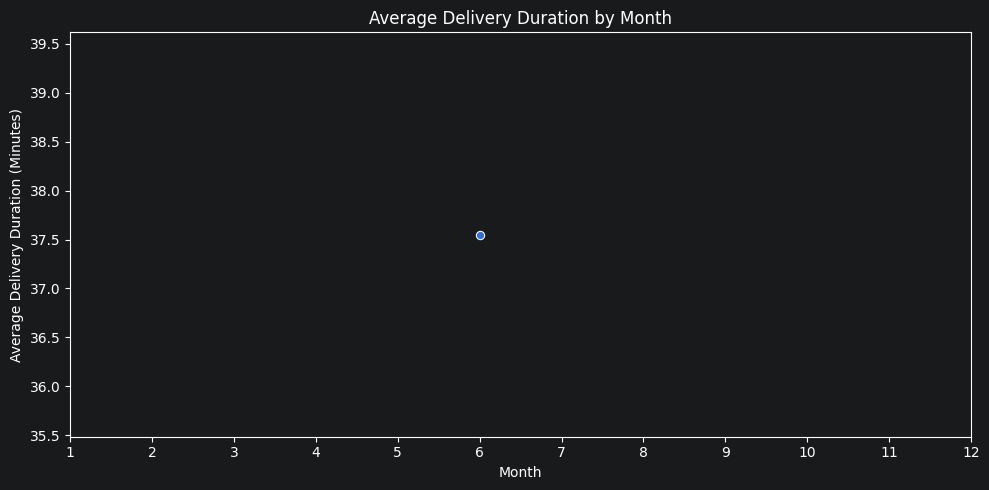

In [19]:
# Average delivery duration by month
if {"Order_Month", "Delivery_Duration_Minutes"}.issubset(df.columns):
    monthly_duration = (
        df.groupby("Order_Month")["Delivery_Duration_Minutes"]
          .mean()
          .sort_index()
    )

    display(monthly_duration.to_frame("Average_Delivery_Duration"))

    plt.figure(figsize=(10, 5))
    sns.lineplot(x=monthly_duration.index, y=monthly_duration.values, marker="o")
    plt.title("Average Delivery Duration by Month")
    plt.xlabel("Month")
    plt.ylabel("Average Delivery Duration (Minutes)")
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.show()


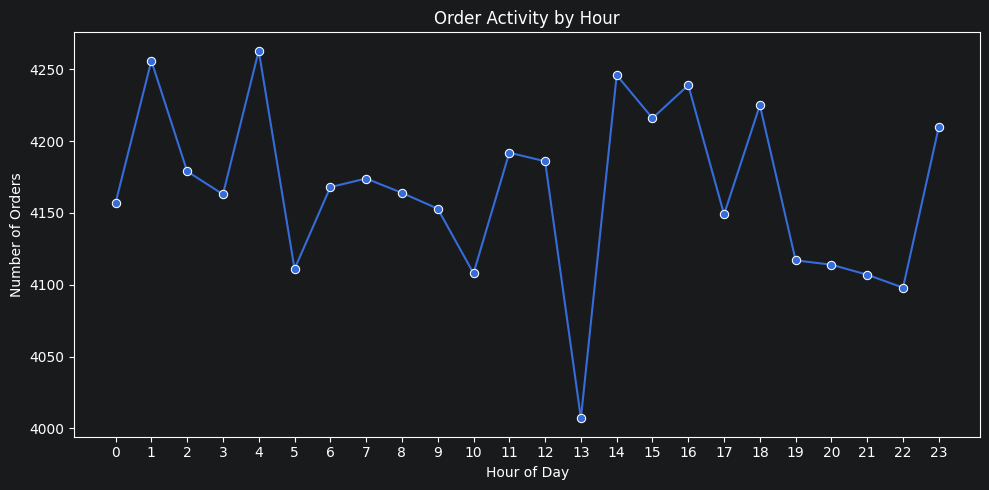

In [20]:
# Order activity by hour
if "Order_Hour" in df.columns:
    hourly_orders = df.groupby("Order_Hour").size().rename("Orders")

    plt.figure(figsize=(10, 5))
    sns.lineplot(x=hourly_orders.index, y=hourly_orders.values, marker="o")
    plt.title("Order Activity by Hour")
    plt.xlabel("Hour of Day")
    plt.ylabel("Number of Orders")
    plt.xticks(range(0, 24))
    plt.tight_layout()
    plt.show()


## 8. Geographic Analysis

The dataset contains restaurant, customer, and driver latitude/longitude.

We use:
- City-level summaries for interpretable geographic comparison
- Delivery distance for quantitative geographic analysis

The raw coordinates are also useful for future mapping in Power BI/Streamlit.


In [21]:
# Geographic summary by city
geo_cols = [c for c in [
    "City", "Delivery_Distance_km", "Delivery_Duration_Minutes",
    "Total_Price"
] if c in df.columns]

if "City" in df.columns:
    geo_summary = (
        df.groupby("City")[geo_cols[1:]]
          .agg(["count", "mean", "median"])
    )
    display(geo_summary)


Delivery_Distance_km              Delivery_Duration_Minutes         \
                          count  mean median                     count   mean   
City                                                                            
Alexandria                14168 2.155  2.108                     12111 37.467   
Assiut                    14302 2.186  2.141                     12220 37.615   
Cairo                     14382 2.160  2.122                     12246 37.454   
Giza                      14232 2.162  2.121                     12094 37.440   
Mansoura                  14044 2.161  2.127                     11946 37.635   
Tanta                     14336 2.162  2.125                     12132 37.571   
Zagazig                   14538 2.171  2.124                     12450 37.674   

                  Total_Price                  
           median       count    mean  median  
City                                           
Alexandria 37.000       14168 271.148 235.785  
Assiut     38.000       14302 268.431 231.995  
Cairo      37.000       14382 268.142 233.905  
Giza       37.000       14232 266.881 231.110  
Mansoura   38.000       14044 267.399 231.710  
Tanta      37.000       14336 271.831 235.670  
Zagazig    38.000       14538 268.613 232.620

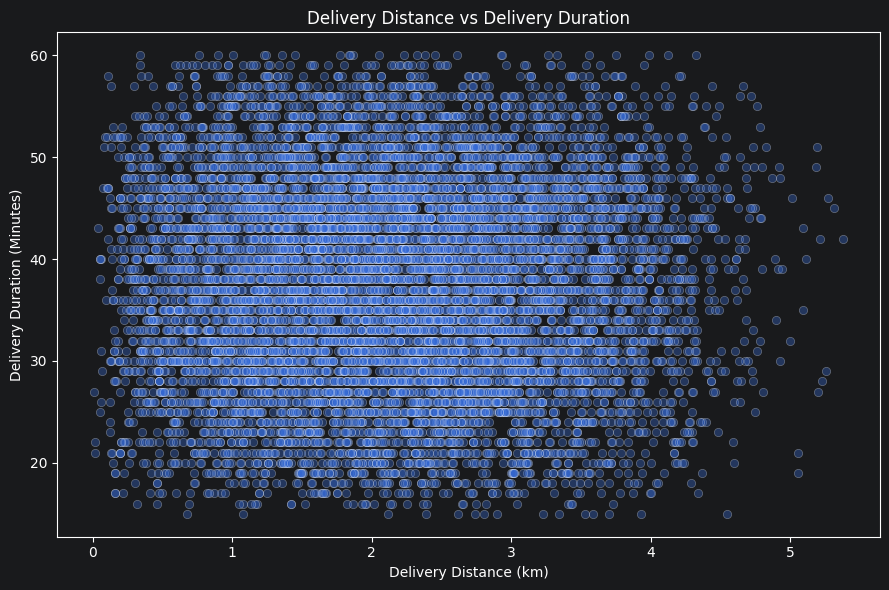

In [22]:
# Distance vs delivery duration
if {"Delivery_Distance_km", "Delivery_Duration_Minutes"}.issubset(df.columns):
    sample = df[["Delivery_Distance_km", "Delivery_Duration_Minutes"]].dropna()

    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=sample.sample(min(10000, len(sample)), random_state=42),
        x="Delivery_Distance_km",
        y="Delivery_Duration_Minutes",
        alpha=0.35
    )
    plt.title("Delivery Distance vs Delivery Duration")
    plt.xlabel("Delivery Distance (km)")
    plt.ylabel("Delivery Duration (Minutes)")
    plt.tight_layout()
    plt.show()


## 9. Relationship Analysis

This section examines business-relevant relationships such as:
- Traffic vs delivery duration
- Distance vs delivery duration
- Traffic vs delivery speed
- City vs delivery performance
- Driver availability vs delivery performance


In [23]:
# Traffic level × order status
if {"Traffic_Level", "Order_Status"}.issubset(df.columns):
    traffic_status = pd.crosstab(
        df["Traffic_Level"],
        df["Order_Status"],
        normalize="index"
    ) * 100

    display(traffic_status.round(2))


Order_Status,Cancelled,Delivered,In Transit
Traffic_Level,,,
High,9.770,85.040,5.190
Low,9.960,85.110,4.930
Medium,9.590,85.530,4.870


In [24]:
# Delivery speed by traffic level
if {"Traffic_Level", "Delivery_Speed_kmh"}.issubset(df.columns):
    speed_traffic = (
        df.groupby("Traffic_Level")["Delivery_Speed_kmh"]
          .agg(["count", "mean", "median", "std"])
          .sort_values("mean", ascending=False)
    )
    display(speed_traffic)


,count,mean,median,std
Traffic_Level,,,,
Medium,21345,3.777,3.417,2.228
High,24850,3.759,3.423,2.225
Low,39004,3.751,3.406,2.227


## 10. Statistical Analysis

### A. Pearson correlation
We test the relationship between delivery distance and delivery duration.

### B. Group comparison
We compare delivery duration across traffic levels using one-way ANOVA when the relevant assumptions are reasonably applicable.

**Interpretation rule:** a p-value below 0.05 indicates evidence of a statistically significant difference/association under the test assumptions. Statistical significance does not by itself imply practical importance or causation.


In [25]:
# Pearson correlation: distance vs duration
if {"Delivery_Distance_km", "Delivery_Duration_Minutes"}.issubset(df.columns):
    pair = df[["Delivery_Distance_km", "Delivery_Duration_Minutes"]].dropna()

    r, p = stats.pearsonr(
        pair["Delivery_Distance_km"],
        pair["Delivery_Duration_Minutes"]
    )

    print(f"Pearson r = {r:.4f}")
    print(f"p-value   = {p:.6g}")


Pearson r = -0.0002
p-value   = 0.950366


In [26]:
# One-way ANOVA: delivery duration across traffic levels
if {"Traffic_Level", "Delivery_Duration_Minutes"}.issubset(df.columns):
    groups = [
        group["Delivery_Duration_Minutes"].dropna().values
        for _, group in df.groupby("Traffic_Level")
    ]

    if len(groups) >= 2:
        f_stat, p_value = stats.f_oneway(*groups)
        print(f"ANOVA F-statistic = {f_stat:.4f}")
        print(f"ANOVA p-value     = {p_value:.6g}")


ANOVA F-statistic = 1.6155
ANOVA p-value     = 0.198802


## 11. Automated Key Findings

The following section calculates a compact set of findings directly from the data so the final report can be based on reproducible results.


In [27]:
findings = []

if "Order_Status" in df.columns:
    status_pct = df["Order_Status"].value_counts(normalize=True) * 100
    top_status = status_pct.index[0]
    findings.append(
        f"The most common order status is '{top_status}' "
        f"({status_pct.iloc[0]:.2f}% of orders)."
    )

if {"Traffic_Level", "Delivery_Duration_Minutes"}.issubset(df.columns):
    traffic_means = df.groupby("Traffic_Level")["Delivery_Duration_Minutes"].mean()
    highest = traffic_means.idxmax()
    lowest = traffic_means.idxmin()
    findings.append(
        f"Average delivery duration is highest under '{highest}' traffic "
        f"({traffic_means[highest]:.2f} minutes) and lowest under '{lowest}' traffic "
        f"({traffic_means[lowest]:.2f} minutes)."
    )

if {"City", "Delivery_Duration_Minutes"}.issubset(df.columns):
    city_means = df.groupby("City")["Delivery_Duration_Minutes"].mean()
    findings.append(
        f"Among cities, '{city_means.idxmax()}' has the highest average delivery duration "
        f"({city_means.max():.2f} minutes), while '{city_means.idxmin()}' has the lowest "
        f"({city_means.min():.2f} minutes)."
    )

if {"Delivery_Distance_km", "Delivery_Duration_Minutes"}.issubset(df.columns):
    pair = df[["Delivery_Distance_km", "Delivery_Duration_Minutes"]].dropna()
    r, p = stats.pearsonr(pair["Delivery_Distance_km"], pair["Delivery_Duration_Minutes"])
    direction = "positive" if r > 0 else "negative"
    findings.append(
        f"Distance and delivery duration show a {direction} Pearson correlation "
        f"(r={r:.3f}, p={p:.3g})."
    )

if {"Traffic_Level", "Delivery_Duration_Minutes"}.issubset(df.columns):
    groups = [
        group["Delivery_Duration_Minutes"].dropna().values
        for _, group in df.groupby("Traffic_Level")
    ]
    if len(groups) >= 2:
        f_stat, p_value = stats.f_oneway(*groups)
        findings.append(
            f"One-way ANOVA across traffic levels gives F={f_stat:.3f}, p={p_value:.3g}."
        )

for i, finding in enumerate(findings, 1):
    print(f"{i}. {finding}")


1. The most common order status is 'Delivered' (85.20% of orders).
2. Average delivery duration is highest under 'Low' traffic (37.60 minutes) and lowest under 'High' traffic (37.46 minutes).
3. Among cities, 'Zagazig' has the highest average delivery duration (37.67 minutes), while 'Giza' has the lowest (37.44 minutes).
4. Distance and delivery duration show a negative Pearson correlation (r=-0.000, p=0.95).
5. One-way ANOVA across traffic levels gives F=1.615, p=0.199.


## 12. Phase 3 Key Findings Summary

Use the automatically generated findings above as the evidence base for the project report.

### Reporting guidance
- Report numerical results with appropriate units.
- Separate descriptive findings from statistical-test results.
- Do not claim causation from correlation.
- Explain practical meaning, not only p-values.
- Use the strongest findings in Power BI and the final presentation.


In [28]:
# Export a compact findings table for reuse in the final report
findings_df = pd.DataFrame({"Key Finding": findings})
display(findings_df)


,Key Finding
0,The most common order status is 'Delivered' (8...
1,Average delivery duration is highest under 'Lo...
2,"Among cities, 'Zagazig' has the highest averag..."
3,Distance and delivery duration show a negative...
4,One-way ANOVA across traffic levels gives F=1....
